# Decision Tree Classifiers

## The Data

We will work with the "Palmer Penguins" dataset.
<!-- 
<figure>
    <img src="penguins.jpg", width='500', style="display: block; margin: 0 auto">
</figure>  -->

Source: Gorman KB, Williams TD, Fraser WR (2014) "*Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis).*" PLoS ONE 9(3): e90081. doi:10.1371/journal.pone.0090081

Summary:
* `penguins_size.csv`: Simplified data from original penguin data sets. Contains variables:

    * `species`: penguin species (Chinstrap, Adélie, or Gentoo)
    * `culmen_length_mm`: culmen length (mm)
    * `culmen_depth_mm`: culmen depth (mm)
    * `flipper_length_mm`: flipper length (mm)
    * `body_mass_g`: body mass (g)
    * `island`: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
    * `sex`: penguin sex



**Goal**: Train a classifier that can help predict a species of a penguin based on physical attributes.

## Imports and DataFrame conversion
* Import the necessary libraries: Pandas, Numpy, Seaborn, and Pyplot.
* Read the `penguin_size.csv` file into a DataFrame called `df`.

In [73]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reading the 'penguin_size.csv' file into a DataFrame
df = pd.read_csv("C:/Users/kevMi/OneDrive/Documents/csFiles-BU/BostonUniversityCS/CS677-BU/HW6_upload/upload/DATA/penguins_size.csv")



* How many features does this data set have? What are they?
* How many data points does this data set have?
* Print the last 6 data points in `df`

In [74]:
# Checking the number of features (columns) and their names
num_features = df.shape[1]
features = df.columns.tolist()

# Checking the number of data points (rows)
num_data_points = df.shape[0]

# Printing the last 6 data points in the DataFrame
last_6_data_points = df.tail(6)

# Displaying the results
print(f"Number of features: {num_features}")
print(f"Feature names: {features}")
print(f"Number of data points: {num_data_points}")
print("\nLast 6 data points:")
print(last_6_data_points)

Number of features: 7
Feature names: ['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Number of data points: 344

Last 6 data points:
    species  island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
338  Gentoo  Biscoe              47.2             13.7              214.0   
339  Gentoo  Biscoe               NaN              NaN                NaN   
340  Gentoo  Biscoe              46.8             14.3              215.0   
341  Gentoo  Biscoe              50.4             15.7              222.0   
342  Gentoo  Biscoe              45.2             14.8              212.0   
343  Gentoo  Biscoe              49.9             16.1              213.0   

     body_mass_g     sex  
338       4925.0  FEMALE  
339          NaN     NaN  
340       4850.0  FEMALE  
341       5750.0    MALE  
342       5200.0  FEMALE  
343       5400.0    MALE  


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,MALE
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE


# Initial Data Analysis

### Finding Missing Data.

* How many features are missing information? Generate a table with the name of the feature and the number of missing features, starting with the feature missing the most data points and going down in decreasing order of missing data points (Hint: can you use the `isna()` method here?).
* What percentage of data points is the top feature entry in your table missing? If this percentage is small enough (roughly less than 10%), drop those data points with missing entries. How many entries are you left with?

In [75]:
# Finding the number of missing values for each feature
missing_data = df.isna().sum()

# Creating a table with the feature name and the number of missing values, sorted in decreasing order
missing_data_sorted = missing_data.sort_values(ascending=False)

# Displaying the table of missing data
print("Missing Data Table (sorted by number of missing values):")
print(missing_data_sorted)

# Calculating the percentage of missing values for the top feature
top_feature_missing_percentage = (missing_data_sorted.iloc[0] / num_data_points) * 100

# Printing the percentage of missing data for the top feature
print(f"\nPercentage of missing data for the top feature: {top_feature_missing_percentage:.2f}%")

# If the missing data percentage is less than 10%, drop those rows
if top_feature_missing_percentage < 10:
    df_cleaned = df.dropna()  # Drop rows with missing values
    num_entries_after_drop = df_cleaned.shape[0]
    print(f"\nNumber of entries remaining after dropping rows with missing data: {num_entries_after_drop}")
else:
    print("\nThe missing data percentage is 10% or more, so we will not drop the rows.")

Missing Data Table (sorted by number of missing values):
sex                  10
culmen_depth_mm       2
culmen_length_mm      2
flipper_length_mm     2
body_mass_g           2
island                0
species               0
dtype: int64

Percentage of missing data for the top feature: 2.91%

Number of entries remaining after dropping rows with missing data: 334


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [8]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


* What values can the `island` feature take? Print them.
* What values can the `sex` feature take? Print them. If there are any data points where the researchers were unable to determine/record the sex of the penguin, remove them from your data frame.
* What values can the label take? Print them.

In [76]:
# Printing the unique values in the 'island' feature
island_values = df['island'].unique()
print("Unique values in the 'island' feature:")
print(island_values)

# Printing the unique values in the 'sex' feature
sex_values = df['sex'].unique()
print("\nUnique values in the 'sex' feature:")
print(sex_values)

# Removing rows where 'sex' is missing (if any)
df_cleaned_sex = df[df['sex'].notna()]

# Printing the number of entries left after removing missing 'sex' entries
print(f"\nNumber of entries after removing missing 'sex' entries: {df_cleaned_sex.shape[0]}")

# Printing the unique values in the label feature
label_values = df['species'].unique()  # Assuming the label feature is 'species'
print("\nUnique values in the label (species) feature:")
print(label_values)

Unique values in the 'island' feature:
['Torgersen' 'Biscoe' 'Dream']

Unique values in the 'sex' feature:
['MALE' 'FEMALE' nan '.']

Number of entries after removing missing 'sex' entries: 334

Unique values in the label (species) feature:
['Adelie' 'Chinstrap' 'Gentoo']


## Data Visualization
* Draw a scatterplot of Culmen Length vs Culmen Depth. Use the classification label as your hue and `palette="Dark2"` for a high-contrast plot.
  * What can you infer from the scatterplot?
* Draw a `pairplot` once again using the classification label as hue.
* Draw a categorical plot of Species vs Culmen Length for the different penguin sexes.
  * Which groups appear better separated for each sex?

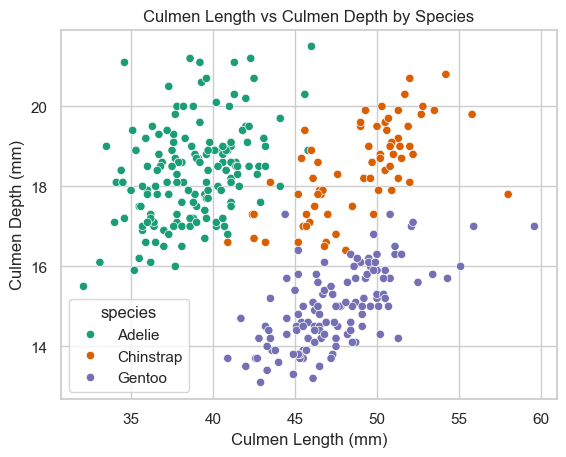

In [80]:
# Scatterplot of Culmen Length vs Culmen Depth with classification label as hue
sns.scatterplot(x='culmen_length_mm', y='culmen_depth_mm', hue='species', data=df, palette="Dark2")

# Adding labels and title
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Culmen Depth (mm)')
plt.title('Culmen Length vs Culmen Depth by Species')
plt.show()


<AxesSubplot:xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

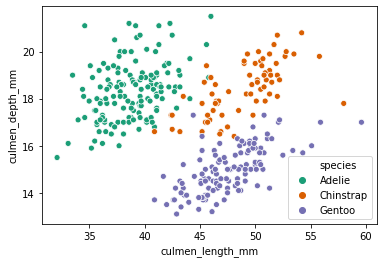

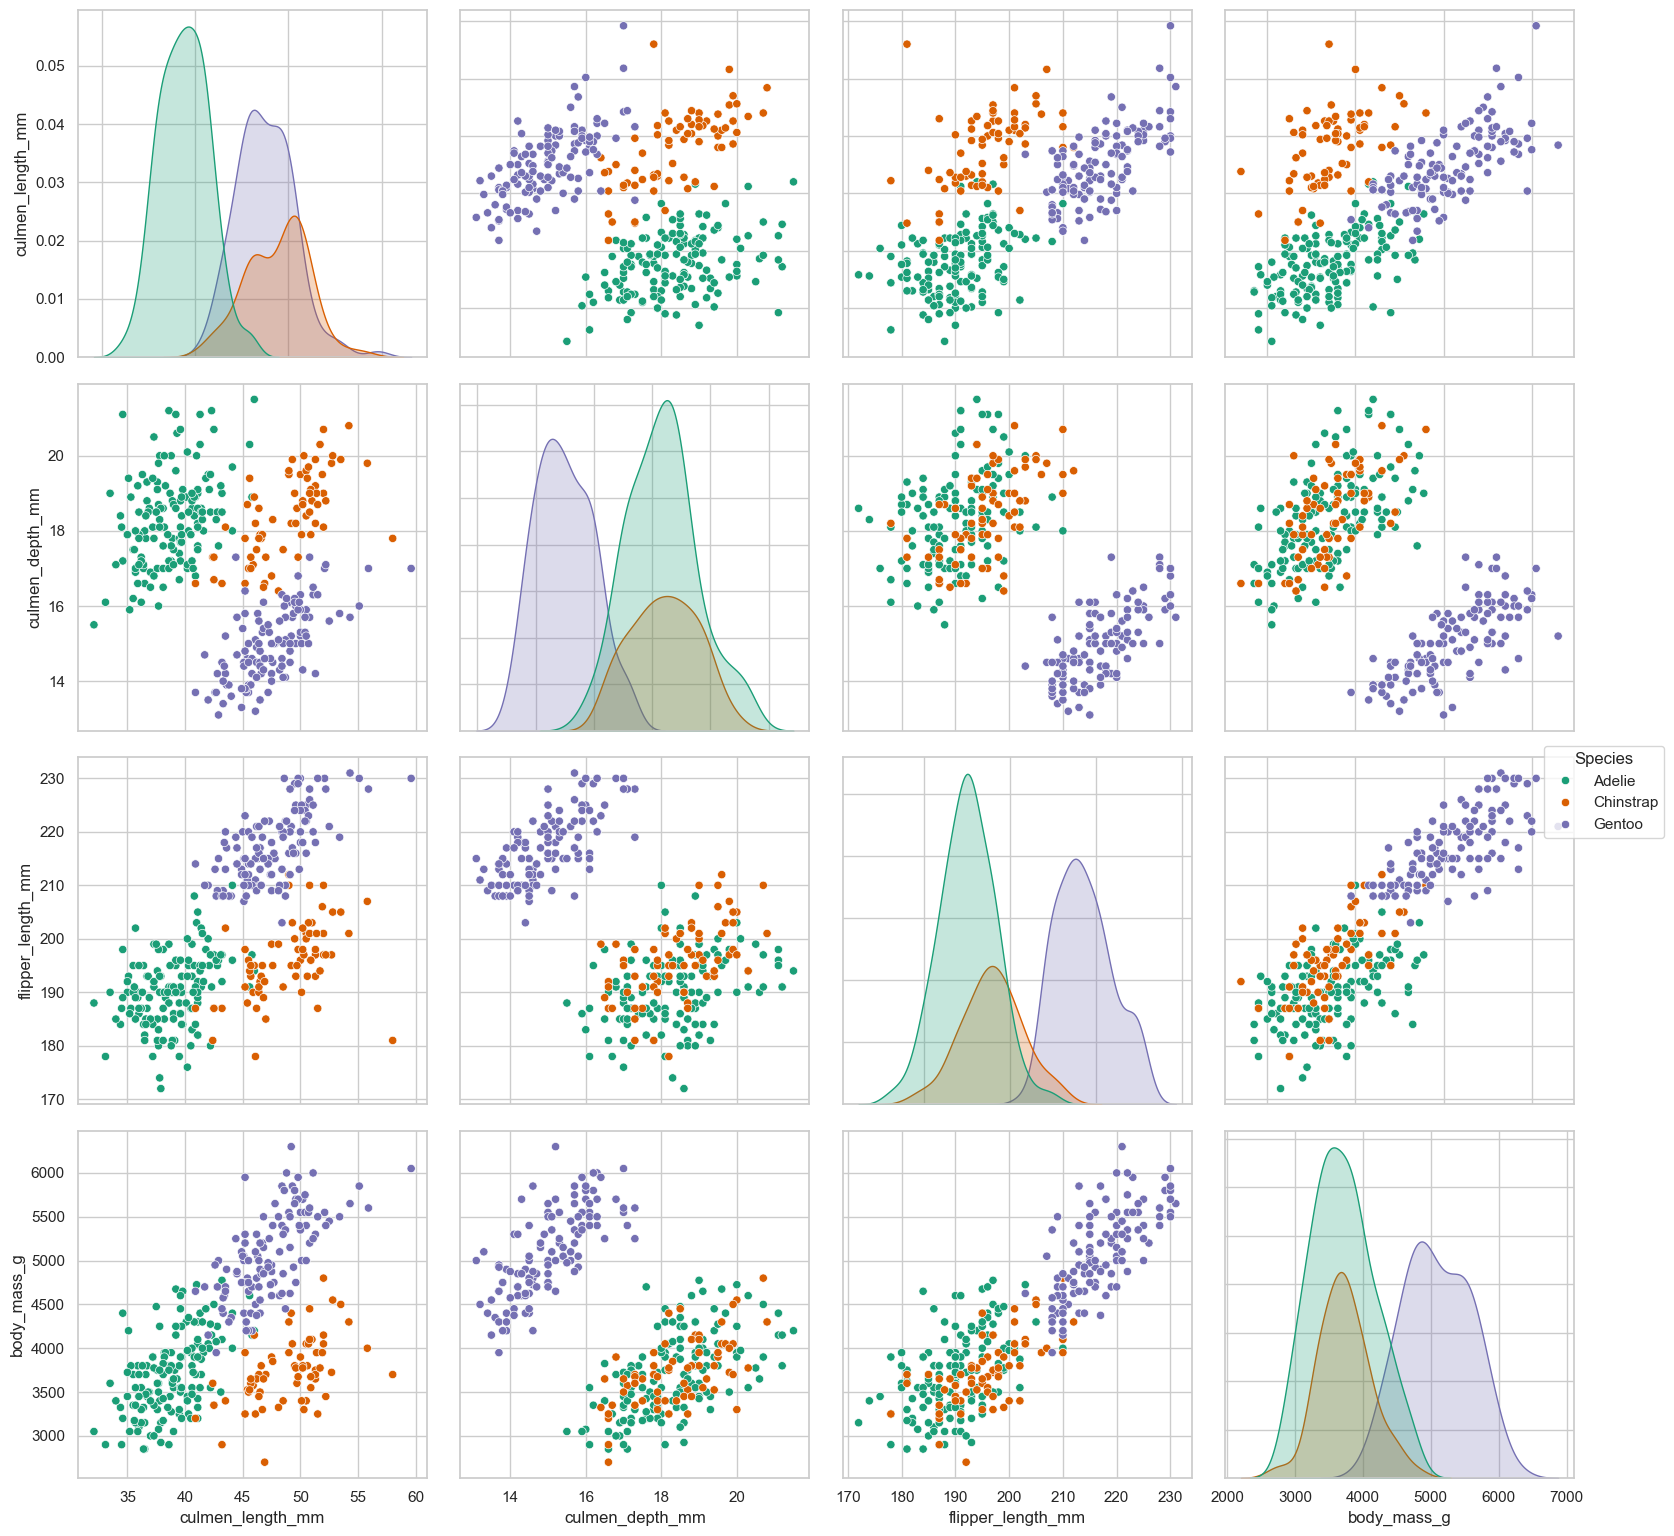

In [97]:
# Define the features
features = ["culmen_length_mm","culmen_depth_mm","flipper_length_mm", "body_mass_g"]

# Create the 4x4 grid of plots
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# We'll collect legend handles/labels from the first plot that generates them
legend_ax = None
handles = labels = None

# Generate plots
for i, y in enumerate(features):
    for j, x in enumerate(features):
        ax = axes[i, j]

        if i == j:
            plot = sns.kdeplot(data=df_cleaned, x=x, hue="species", palette="Dark2", fill=True, ax=ax, legend=True)
        else:
            plot = sns.scatterplot(data=df_cleaned, x=x, y=y, hue="species", palette="Dark2", ax=ax, legend=True)

        # Capture handles/labels from the first non-empty legend
        if handles is None and ax.get_legend_handles_labels()[0]:
            handles, labels = ax.get_legend_handles_labels()
            legend_ax = ax

        # Remove individual legends
        ax.legend_.remove() if ax.get_legend() else None

        # Label only outer axes
        if i == len(features) - 1:
            ax.set_xlabel(x)
        else:
            ax.set_xlabel('')
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(y)
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])


# Add a single global legend at the bottom
if handles and labels:
    fig.legend(handles, labels, loc='center right', title='Species', bbox_to_anchor=(1.05, 0.5))

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

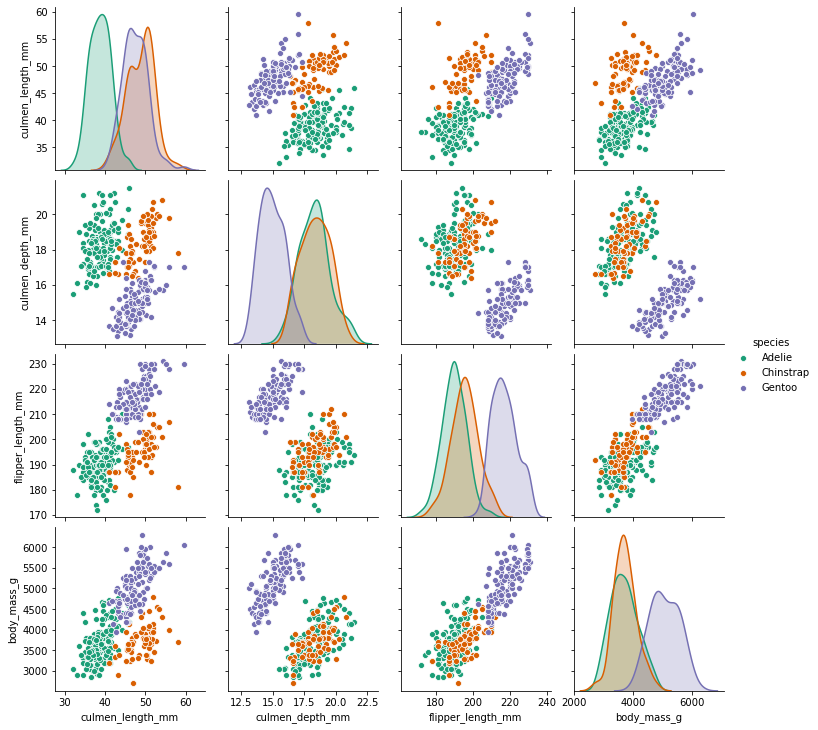

C:\Users\kevMi\AppData\Local\Temp\ipykernel_4768\3644182313.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=male_df, x='species', y='culmen_length_mm',palette="Dark2", ax=axs[0])
C:\Users\kevMi\AppData\Local\Temp\ipykernel_4768\3644182313.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=female_df, x='species', y='culmen_length_mm',palette="Dark2", ax=axs[1])


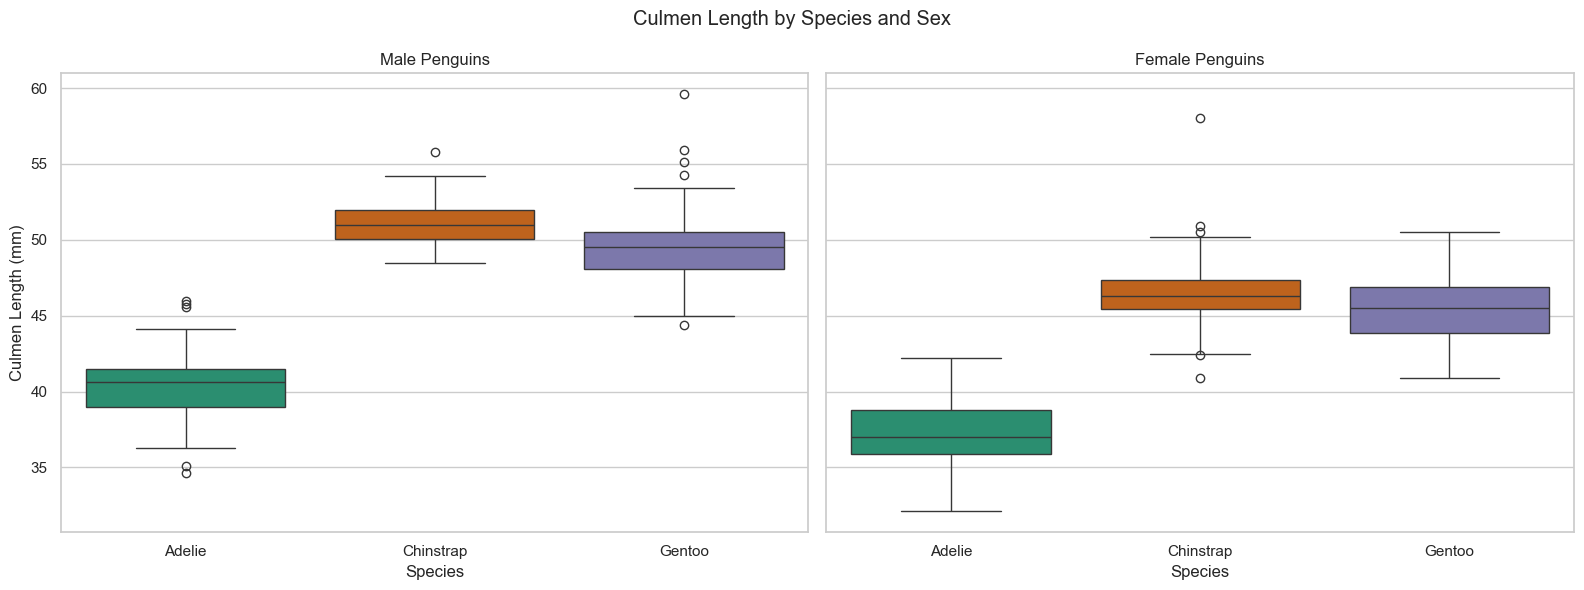

In [98]:
  # Split into male and female groups
male_df = df_cleaned_sex[df_cleaned_sex['sex'] == 'MALE']
female_df = df_cleaned_sex[df_cleaned_sex['sex'] == 'FEMALE']

# Set up the figure
sns.set(style="whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Boxplot for Male Penguins
sns.boxplot(data=male_df, x='species', y='culmen_length_mm',palette="Dark2", ax=axs[0])
axs[0].set_title('Male Penguins')
axs[0].set_xlabel('Species')
axs[0].set_ylabel('Culmen Length (mm)')

# Boxplot for Female Penguins
sns.boxplot(data=female_df, x='species', y='culmen_length_mm',palette="Dark2", ax=axs[1])
axs[1].set_title('Female Penguins')
axs[1].set_xlabel('Species')
axs[1].set_ylabel('')

# Final layout
plt.suptitle('Culmen Length by Species and Sex')
plt.tight_layout()
plt.show()

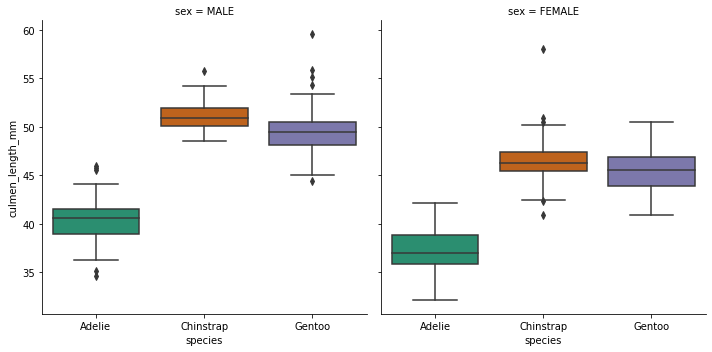

## Feature Engineering
* We will now one-hot encode the categorical features.
* Research the `get_dummies()` method on the Scikit-Learn website and use it to one-hot encode `species`, `island`, and `sex`.
  * Your data frame post-encoding should look like this.

In [99]:
# One-hot encode 'species', 'island', and 'sex'
df_encoded = pd.get_dummies(df_cleaned, columns=['species', 'island', 'sex'])

# Show the first few rows
print(df_encoded.head())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0              39.1             18.7              181.0       3750.0   
1              39.5             17.4              186.0       3800.0   
2              40.3             18.0              195.0       3250.0   
4              36.7             19.3              193.0       3450.0   
5              39.3             20.6              190.0       3650.0   

   species_Adelie  species_Chinstrap  species_Gentoo  island_Biscoe  \
0            True              False           False          False   
1            True              False           False          False   
2            True              False           False          False   
4            True              False           False          False   
5            True              False           False          False   

   island_Dream  island_Torgersen  sex_.  sex_FEMALE  sex_MALE  
0         False              True  False       False      True  
1         

Once you're done, observe that for every categorical feature that can take $L$ values, you only need $L-1$ columns. Why?
When you one-hot encode a categorical variable with L possible values, each value becomes a separate binary column. However, keeping all L columns introduces multicollinearity, especially in models like linear or logistic regression.
This happens because if you know the values of L−1 columns, you can always infer the last one. So one of the columns is redundant — it's a linear combination of the others

In [100]:
# One-hot encode island and sex only (not species)
df_encoded = pd.get_dummies(df_cleaned, columns=['island', 'sex'], drop_first=True)

# Features and multiclass label
X = df_encoded.drop(columns=['species'])  # features
y = df_encoded['species']                # target: 3 classes


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,0,1,1
1,39.5,17.4,186.0,3800.0,0,1,0
2,40.3,18.0,195.0,3250.0,0,1,0
4,36.7,19.3,193.0,3450.0,0,1,0
5,39.3,20.6,190.0,3650.0,0,1,1
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,0,0,0
340,46.8,14.3,215.0,4850.0,0,0,0
341,50.4,15.7,222.0,5750.0,0,0,1
342,45.2,14.8,212.0,5200.0,0,0,0


## Train | Test Split
* Separate the data frame into features and labels.
* Create training and testing sets with a (70:30) split. Use `random_state = 101`.
* Train your `DecisionTreeClassifier` with default parameters.
* While accuracy is the usual metric for classification, we will employ a Confusion Matrix instead.
  * Generate the confusion matrix for your fitted model. The information given in Chapter 3, page 108 of the course textbook (which you should have read by now but didn't) might come in handy.
* Also, draw the trained decision tree.
  * I have used the `plot_tree()` method along with the `filled` and `feature_names` parameters, but you may use `export_graphviz` instead.

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Features and multiclass label
X = df_encoded.drop(columns=['species'])  # features
y = df_encoded['species']                # target: 3 classes

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Train Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=101)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

array([[38,  2,  0],
       [ 1, 26,  0],
       [ 1,  0, 32]], dtype=int64)

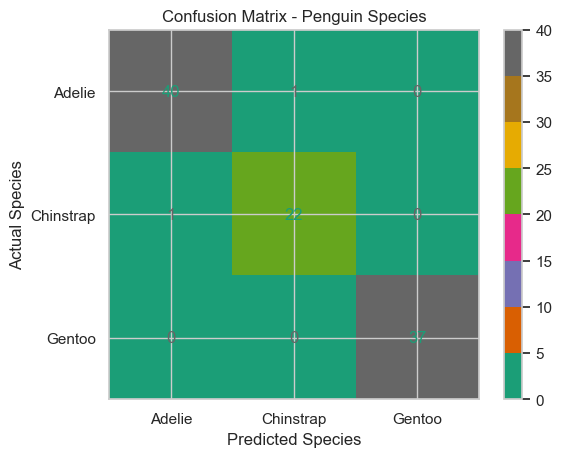

In [103]:
# Predict and Confusion Matrix
y_pred = dtree.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Display Confusion Matrix with labels
class_names = ['Adelie', 'Chinstrap', 'Gentoo']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Dark2", values_format='d')
plt.title("Confusion Matrix - Penguin Species")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

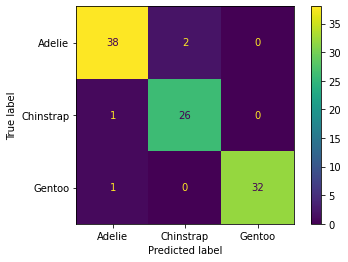

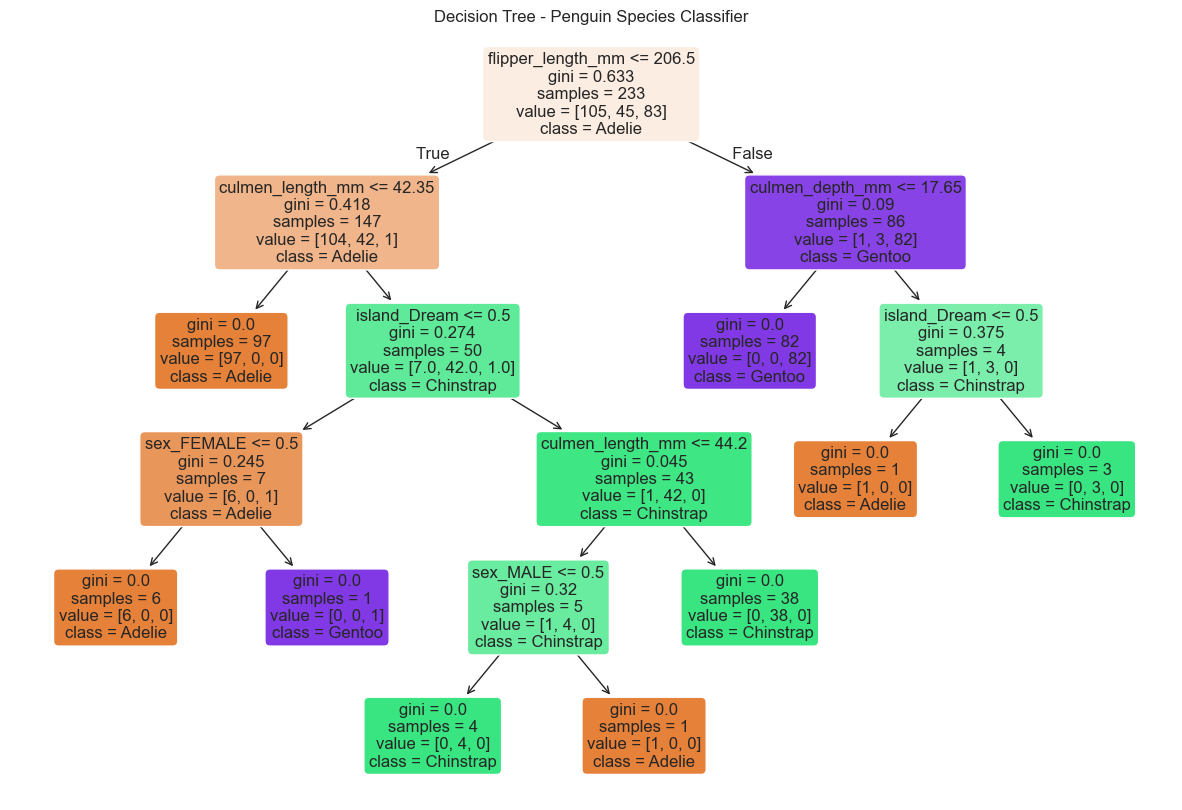

In [104]:
# Visualize the trained Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(dtree, filled=True, feature_names=X.columns, class_names=class_names, rounded=True, fontsize=12)
plt.title("Decision Tree - Penguin Species Classifier")
plt.show()

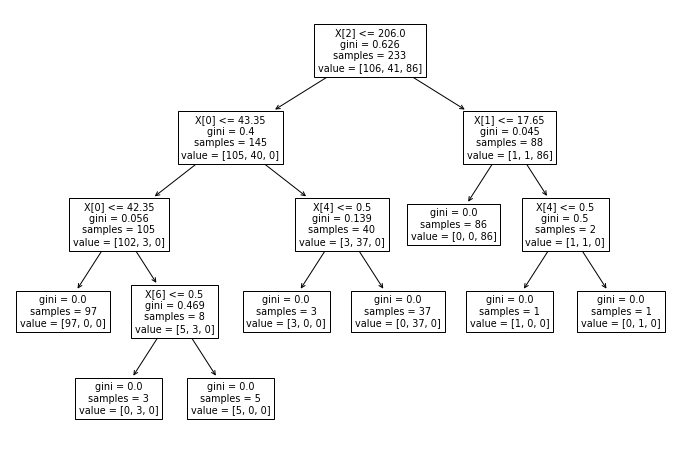

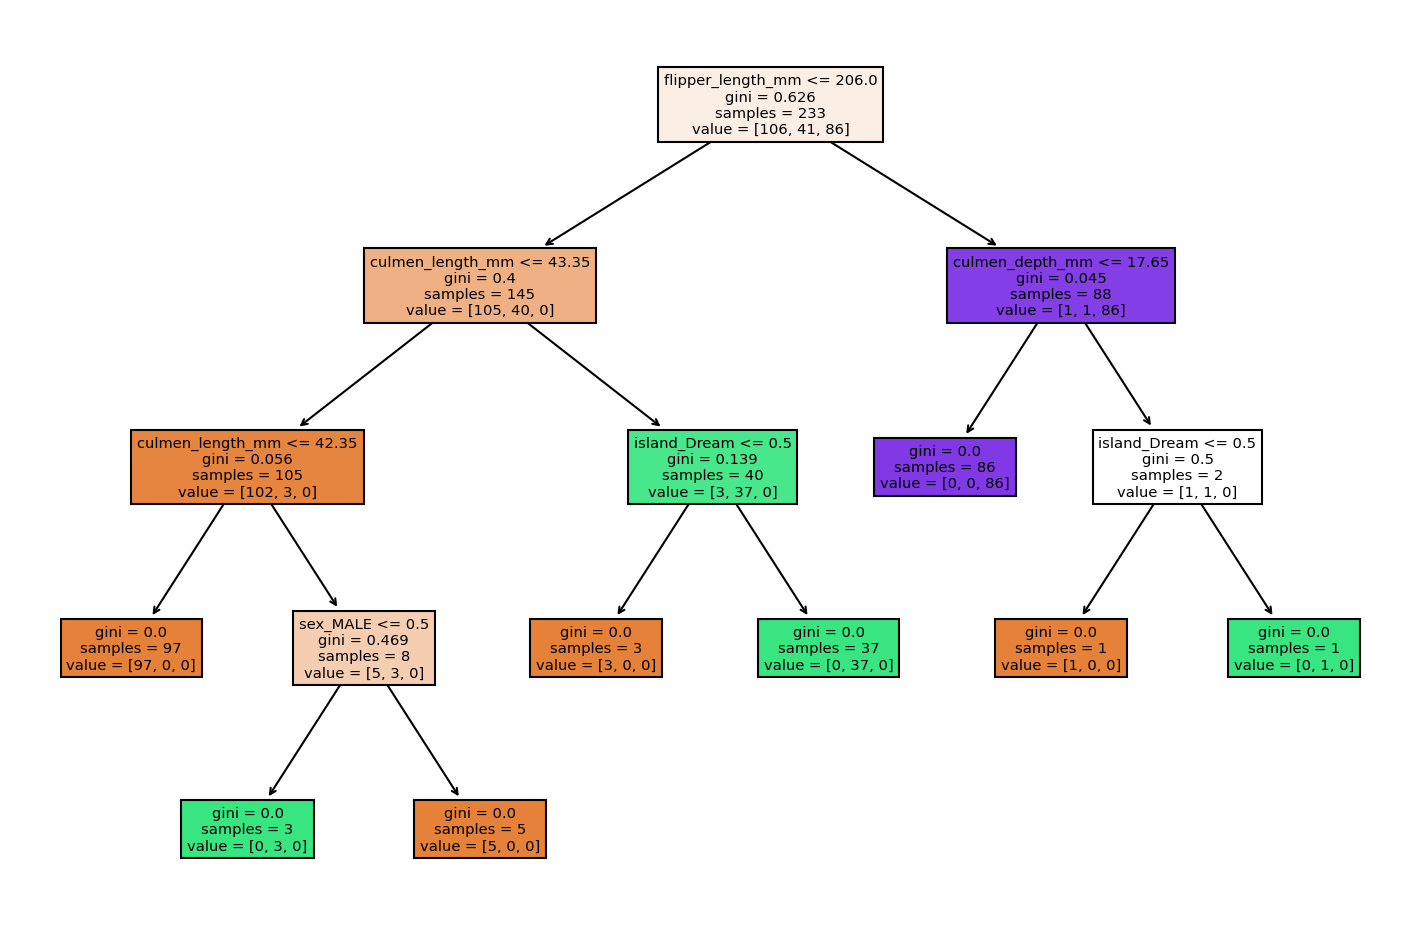

## Understanding Hyperparameters
* Retrain the tree with a maximum depth of 2 and draw the tree.
* Retrain the tree with maximum of 3 leaves and draw the tree.
* Use Entropy instead of Gini Index and retrain the tree.

---